**Imports**

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os 

from skimage.filters import threshold_niblack, threshold_sauvola
from skimage import img_as_float
from skimage.morphology import remove_small_objects

**Metrics**

In [20]:
def dice_score(pred, gt):
  intersection = np.logical_and(pred, gt).sum()
  return 2 * intersection / (pred.sum() + gt.sum() + 1e-8)

def jaccard_score(pred, gt):
  intersection = np.logical_and(pred, gt).sum()
  union = np.logical_or(pred, gt).sum()
  return intersection / (union + 1e-8)


**Paths**

In [5]:
base_path = r'C:\V\sem_6_notes\DL_MedicalImage_processing\DigitalRetinaImages\DRIVE\training'

img_dir = os.path.join(base_path, "images")
gt_dir = os.path.join(base_path, "1st_manual")
mask_dir = os.path.join(base_path,"mask")

In [9]:
img_dir

'C:\\V\\sem_6_notes\\DL_MedicalImage_processing\\DigitalRetinaImages\\DRIVE\\training\\images'

In [10]:
os.path.exists(img_dir)

True

**Parameters**

In [39]:
window = 25
k_sauvola = 0.2
k_niblack = 0.6
min_size = 50

**Single Image Test**

In [24]:
import re

filename = sorted(os.listdir(img_dir))[0]

# Extract numeric ID (21, 22, etc.)
img_id = re.findall(r'\d+', filename)[0]

img_path = os.path.join(img_dir, filename)
gt_path = os.path.join(gt_dir, f"{img_id}_manual1.gif")
mask_path = os.path.join(mask_dir, f"{img_id}_training_mask.gif")

img = cv2.imread(img_path)
gt = cv2.imread(gt_path, 0)
mask = cv2.imread(mask_path, 0)

print(img is None, gt is None, mask is None)

False False False


In [25]:

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gt = gt > 0
mask = mask > 0

green = img_as_float(img_rgb[:, :, 1])

green_uint8 = (green * 255).astype(np.uint8)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = img_as_float(clahe.apply(green_uint8))

In [40]:
# Sauvola
thresh_sau = threshold_sauvola(enhanced, window_size=window, k=k_sauvola)
binary_sau = enhanced > thresh_sau

# Niblack
thresh_nib = threshold_niblack(enhanced, window_size=window, k=k_niblack)
binary_nib = enhanced > thresh_nib

# Remove noise
binary_sau = remove_small_objects(binary_sau, min_size=min_size)
binary_nib = remove_small_objects(binary_nib, min_size=min_size)

# Apply FOV mask (CRITICAL)
binary_sau = binary_sau & mask
binary_nib = binary_nib & mask

print("Sauvola Dice:", dice_score(binary_sau, gt))
print("Sauvola Jaccard:", jaccard_score(binary_sau, gt))

print("Niblack Dice:", dice_score(binary_nib, gt))
print("Niblack Jaccard:", jaccard_score(binary_nib, gt))

Sauvola Dice: 0.08898999871227672
Sauvola Jaccard: 0.04656699789760981
Niblack Dice: 0.056719725480430874
Niblack Jaccard: 0.029187619626537663


C:\Users\ROG\AppData\Local\Temp\ipykernel_9244\1606304966.py:10: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary_sau = remove_small_objects(binary_sau, min_size=min_size)
C:\Users\ROG\AppData\Local\Temp\ipykernel_9244\1606304966.py:11: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary_nib = remove_small_o

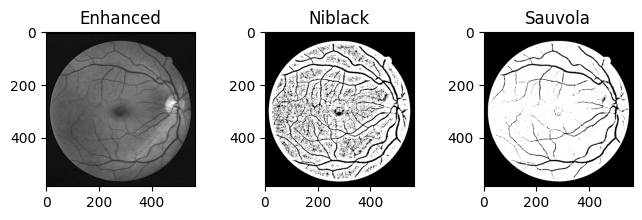

In [41]:
plt.figure(figsize=(8,2))

plt.subplot(1,3,1)
plt.imshow(enhanced, cmap='gray')
plt.title("Enhanced")

plt.subplot(1,3,2)
plt.imshow(binary_nib, cmap='gray')
plt.title("Niblack")

plt.subplot(1,3,3)
plt.imshow(binary_sau, cmap='gray')
plt.title("Sauvola")

plt.show()

**Full dataset Evaluation**

In [42]:
import re

dice_sau_list = []
dice_nib_list = []

for filename in sorted(os.listdir(img_dir)):

    img_id = re.findall(r'\d+', filename)[0]

    img_path = os.path.join(img_dir, filename)
    gt_path = os.path.join(gt_dir, f"{img_id}_manual1.gif")
    mask_path = os.path.join(mask_dir, f"{img_id}_training_mask.gif")

    img = cv2.imread(img_path)
    gt = cv2.imread(gt_path, 0)
    mask = cv2.imread(mask_path, 0)

    if img is None or gt is None or mask is None:
        print("File error:", filename)
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gt = gt > 0
    mask = mask > 0

    green = img_as_float(img_rgb[:, :, 1])
    green_uint8 = (green * 255).astype(np.uint8)

    enhanced = img_as_float(clahe.apply(green_uint8))

    thresh_sau = threshold_sauvola(enhanced, window_size=window, k=k_sauvola)
    thresh_nib = threshold_niblack(enhanced, window_size=window, k=k_niblack)

    binary_sau = remove_small_objects(enhanced > thresh_sau, min_size=min_size)
    binary_nib = remove_small_objects(enhanced > thresh_nib, min_size=min_size)

    binary_sau = binary_sau & mask
    binary_nib = binary_nib & mask

    dice_sau_list.append(dice_score(binary_sau, gt))
    dice_nib_list.append(dice_score(binary_nib, gt))

print("Average Sauvola Dice:", np.mean(dice_sau_list))
print("Average Niblack Dice:", np.mean(dice_nib_list))

C:\Users\ROG\AppData\Local\Temp\ipykernel_9244\3115668299.py:35: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary_sau = remove_small_objects(enhanced > thresh_sau, min_size=min_size)
C:\Users\ROG\AppData\Local\Temp\ipykernel_9244\3115668299.py:36: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary_nib = rem

Average Sauvola Dice: 0.12460703062231834
Average Niblack Dice: 0.08189567391765616
